In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.linalg import cholesky # computes upper triangle by default, matches paper
import random
from mpl_toolkits.mplot3d import Axes3D

In [20]:
def random_spd_matrix(n):
    A = np.random.rand(n, n)
    return np.dot(A, A.transpose())

In [21]:
# Example: Generate a 2x2 random symmetric positive definite matrix
n = 19
spd_matrix = random_spd_matrix(n)

In [22]:
eigenvalues, eigenvectors = np.linalg.eigh(spd_matrix, UPLO='L')

In [23]:
descending_indices = np.argsort(eigenvalues)[::-1]
top_eigenvalues = eigenvalues[descending_indices[:3]]
top_eigenvectors =  eigenvectors[:, descending_indices[:3]]

In [34]:
#coefs = np.sqrt(1/top_eigenvalues)
coefs = top_eigenvalues

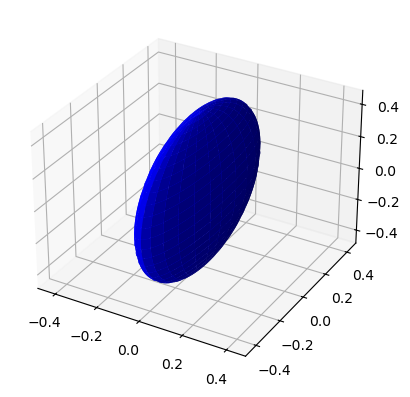

In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=plt.figaspect(1))  # Square figure
ax = fig.add_subplot(111, projection='3d')

#coefs = (1, 2, 2)  # Coefficients in a0/c x**2 + a1/c y**2 + a2/c z**2 = 1 
# Radii corresponding to the coefficients:
rx, ry, rz = 1/np.sqrt(coefs)

# Set of all spherical angles:
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

# Cartesian coordinates that correspond to the spherical angles:
# (this is the equation of an ellipsoid):
x = rx * np.outer(np.cos(u), np.sin(v))
y = ry * np.outer(np.sin(u), np.sin(v))
z = rz * np.outer(np.ones_like(u), np.cos(v))

# Plot:
ax.plot_surface(x, y, z,  rstride=4, cstride=4, color='b')

# Adjustment of the axes, so that they all have the same span:
max_radius = max(rx, ry, rz)
for axis in 'xyz':
    getattr(ax, 'set_{}lim'.format(axis))((-max_radius, max_radius))

plt.show()

In [1]:
def sample(S, z_hat, m_FA, Gamma_Threshold=1.0):
    # Based on https://www.onera.fr/sites/default/files/297/C013_-_Dezert_-_YBSTributeMonterey2001.pdf
    # And https://math.stackexchange.com/questions/2174751/generate-random-points-within-n-dimensional-ellipsoid
    nz = S.shape[0]
    z_hat = z_hat.reshape(nz,1)

    X_Cnz = np.random.normal(size=(nz, m_FA))

    rss_array = np.sqrt(np.sum(np.square(X_Cnz),axis=0))
    kron_prod = np.kron( np.ones((nz,1)), rss_array)

    X_Cnz = X_Cnz / kron_prod       # Points uniformly distributed on hypersphere surface

    R = np.ones((nz,1))*( np.power( np.random.rand(1,m_FA), (1./nz)))

    unif_sph=R*X_Cnz;               # m_FA points within the hypersphere
    T = np.asmatrix(cholesky(S))    # Cholesky factorization of S => S=T’T


    unif_ell = T.H*unif_sph ; # Hypersphere to hyperellipsoid mapping

    # Translation and scaling about the center
    z_fa=(unif_ell * np.sqrt(Gamma_Threshold)+(z_hat * np.ones((1,m_FA))))

    return np.array(z_fa)

In [2]:
points = sample(S=spd_matrix, z_hat=np.zeros(n), m_FA=2000, Gamma_Threshold=1.0).T

NameError: name 'spd_matrix' is not defined

NameError: name 'np' is not defined

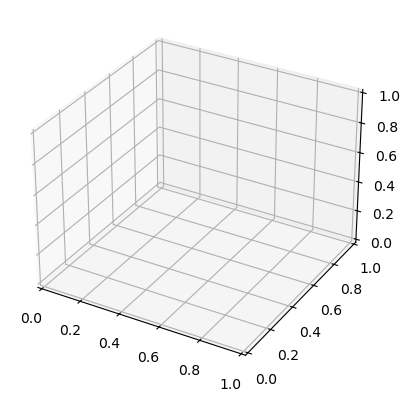

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
points = np.array(points)
points = PCA(n_components=3).fit_transform(points)
ax.scatter(points[:, 0], points[:, 1], points[:, 2])
# set aspect ratio for the axes using https://stackoverflow.com/a/64453375/8565438
ax.set_box_aspect((np.ptp(points[:, 0]), np.ptp(points[:, 1]), np.ptp(points[:, 2])))
plt.show()

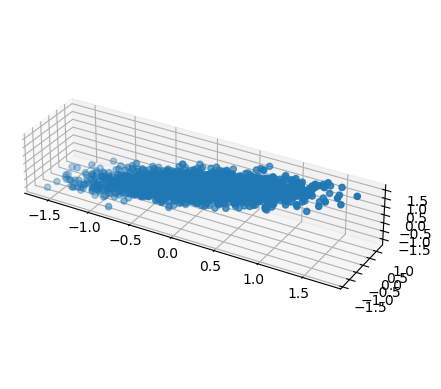

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
points_pca = PCA(n_components=3).fit_transform(points)
ax.scatter(points[:, 0], points[:, 1], points[:, 2])
# set aspect ratio for the axes using https://stackoverflow.com/a/64453375/8565438
ax.set_box_aspect((np.ptp(points_pca[:, 0]), np.ptp(points_pca[:, 1]), np.ptp(points_pca[:, 2])))
plt.show()

In [ ]:
def NDimEllipsoid(x, y):
    return np.sum(np.square(x / np.square(y)))

In [67]:
def V_ellipsoid(axes, N):
    valid_points = []
    while len(valid_points) < N:
        point = np.zeros(axes.shape[0])
        for axes_idx in range(axes.shape[0]):
            point[axes_idx] = random.uniform(-axes[axes_idx], axes[axes_idx])
        if NDimEllipsoid(point,axes) <= 1:
            valid_points.append(point)
    return valid_points

In [68]:
valid_points = V_ellipsoid(axes, N=100)

In [37]:
def plot_vectors_as_ellipse(v1, v2, center=(0, 0), ax=None, **kwargs):
    """
    Plots two vectors as an ellipse.

    Args:
        v1 (np.array): First vector (semi-major axis).
        v2 (np.array): Second vector (semi-minor axis).
        center (tuple): Center of the ellipse.
        ax (matplotlib.axes.Axes): Axes object to plot on. If None, a new figure and axes will be created.
        **kwargs: Additional keyword arguments passed to the Ellipse patch.
    """
    angle = np.degrees(np.arctan2(v1[1], v1[0]))
    width = 2 * np.linalg.norm(v1)
    height = 2 * np.linalg.norm(v2)

    if ax is None:
        fig, ax = plt.subplots()

    ellipse = Ellipse(center, width, height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

    # Set plot limits to ensure the ellipse is fully visible
    max_range = max(width, height) / 2 + max(abs(center[0]), abs(center[1]))
    ax.set_xlim([center[0] - max_range, center[0] + max_range])
    ax.set_ylim([center[1] - max_range, center[1] + max_range])
    #ax.set_aspect('equal', adjustable='box') 

    return ax

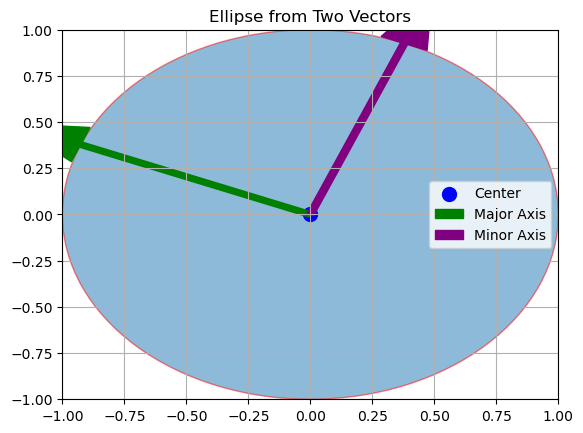

In [38]:
 # Example usage:
v1 = eigenvectors[:, 0]  # Semi-major axis vector
v2 = eigenvectors[:, 1] # Semi-minor axis vector
center = (0, 0)

ax = plot_vectors_as_ellipse(v1, v2, center=center, alpha=0.5, edgecolor='r')
ax.scatter(*center, color='blue', s=100, label='Center') # Plot center point
ax.arrow(*center, *v1, color='green', width=0.03, head_width=0.2, label='Major Axis') # Plot vector v1
ax.arrow(*center, *v2, color='purple', width=0.03, head_width=0.2, label='Minor Axis') # Plot vector v2
ax.legend()
plt.title('Ellipse from Two Vectors')
plt.grid(True)
plt.show()